# 📜 Proyecto final - Machine Learning #
#### 🖊️ Grupo 2 - Ineta Keryte, Anthonny Maldonado, Guillermo Mansanta ####

Este es el proyecto final de nuestro bootcamp de Machine Learning, donde demostramos las habilidades y conocimientos adquiridos a lo largo de nuestros estudios. A lo largo de este bootcamp, hemos estudiado diferentes modelos basados en proyectos de diferentes áreas y tipos. Ahora es el momento de crear nuestro propio proyecto utilizando el algoritmo que creemos que se adapta mejor a nuestro problema.

In [71]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
import streamlit as st
import pickle
import re
import json
import unicodedata

### 👩‍⚕️ Nuestro problema a resolver 👨🏻‍⚕️ ###

<p style="text-align: justify;">
En el contexto macroeconómico argentino, atravesado por inflación, inestabilidad en los precios y restricciones en el acceso al financiamiento, la gestión de inventarios se convierte en un factor crítico para la sostenibilidad de cualquier farmacia. La falta de una planificación de stock basada en criterios técnicos y analíticos impacta directamente tanto en la rentabilidad del negocio como en la calidad del servicio prestado a la comunidad.

Desde la perspectiva comercial, una mala política de inventarios genera una utilización ineficiente del capital de trabajo, con recursos financieros inmovilizados en mercadería de baja rotación o con riesgo de vencimiento. Esto incrementa los costos operativos, deteriora el flujo de caja y limita la capacidad de negociación con droguerías y laboratorios, afectando condiciones de pago, descuentos y líneas de crédito.

Desde la perspectiva del servicio farmacéutico, los errores de planificación derivan en quiebres de stock de medicamentos esenciales, demoras en la atención, pérdida de continuidad en tratamientos y disminución de la confianza de los pacientes y clientes. La farmacia deja de ser percibida como un punto de referencia sanitario confiable y pasa a ser vista como un comercio reactivo e ineficiente.

En conjunto, la ausencia de una gestión profesional del inventario compromete simultáneamente la competitividad económica del negocio y su rol social como prestador de un servicio de salud.

👉 ## Problema real: la farmacia no cuenta con una metodología objetiva para anticipar la demanda futura de sus productos.
</p>


### 🎯 Objetivo de nuestro proyecto ### 

<p style="text-align: justify;">
Este proyecto tiene como objetivo aplicar técnicas de Machine Learning para mejorar la forma en que una farmacia gestiona su stock. A partir del análisis de las ventas de un año completo (2025) de una farmacia ubicada en la provincia de Buenos Aires, se busca entender cómo se comporta la demanda de los productos y usar esa información para planificar mejor el inventario del año 2026. La idea principal es pasar de una gestión basada solo en la experiencia a una gestión basada en datos, que permita anticiparse a las necesidades de los clientes, evitar faltantes de productos importantes y reducir el exceso de mercadería en un contexto económico cambiante. Todo el enfoque está pensado desde la realidad del negocio farmacéutico y el comportamiento de consumo de las personas.
</p>

### Dataset - Carga de conjunto de datos 💊

In [72]:
df = pd.read_csv("../data/raw/farmacia-datos.csv", sep=";", encoding="latin1")
df.head()

,Fecha,Tipo Mov.,Fac. Tipo,Fac. Suc.,Fac. Nun.,Fisc. Numero,Tipo Pago,Cant.,Precio,Producto,Sub. Total,Rubro,Cobertura,Ajustes,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar
0,01/01/25 01.13.46,F,B,0,379923,NaN,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,NaN,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,NaN,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"


<p style="text-align: justify;">
El dataset contiene información de registro de ventas durante el año 2025 de una farmacia situada en Argentina, en la provincia de Buenos Aires. El registro se corresponde a los datos de los tickets de venta generados durante todo el año, los días que el comercio estuvo abierto. Teniendo en cuenta que el comercio trabaja de Lunes a Sábados de 8hs a 20 hs, es decir, 12 hs por día, se han generado un total de datos tal que nuestro dataset contiene:
</p>

- 117.415 filas

- 20 columnas, con variables categoricas y numericas como: ['Fecha', 'Tipo Mov.', 'Fac. Tipo', 'Fac. Suc.', 'Fac. Nun.','Fisc. Numero', 'Tipo Pago', 'Cant.', 'Precio', 'Producto', 'Sub. Total', 'Rubro', 'Cobertura', 'Ajustes', 'Desc. Adic.', 'Total. Cliente', 'IVA', 'Tasa Iva', 'Total Gravado', 'Total sin Gravar']

- Más de 7.500 productos distintos

- Rubro farmacia (medicamentos, insumos médicos, suplementos, vitaminas, salud preventiva) y perfumería y cuidado personal (cremas, protectores, higiene).
<p style="text-align: justify;">
Se trata de un conjunto de datos reales, lo que implica la presencia de ruido, valores inconsistentes, formatos heterogéneos y registros incompletos, características habituales en fuentes operativas del sector farmacéutico. Esta naturaleza del dataset representó un desafío significativo durante la etapa de data cleaning, ya que fue necesario aplicar múltiples técnicas de depuración, normalización y validación para garantizar la calidad de los datos antes de avanzar con el análisis y el modelado.
</p>

In [73]:
df.shape

(117415, 20)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117415 entries, 0 to 117414
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Fecha             117415 non-null  object 
 1   Tipo Mov.         117415 non-null  object 
 2   Fac. Tipo         117415 non-null  object 
 3   Fac. Suc.         117415 non-null  int64  
 4   Fac. Nun.         117415 non-null  int64  
 5   Fisc. Numero      0 non-null       float64
 6   Tipo Pago         117415 non-null  object 
 7   Cant.             117415 non-null  int64  
 8   Precio            117415 non-null  object 
 9   Producto          117414 non-null  object 
 10  Sub. Total        117415 non-null  object 
 11  Rubro             117415 non-null  object 
 12  Cobertura         117415 non-null  object 
 13  Ajustes           117415 non-null  int64  
 14  Desc. Adic.       117415 non-null  object 
 15  Total. Cliente    117415 non-null  object 
 16  IVA               11

In [75]:
df.duplicated().sum()

np.int64(121)

In [76]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.duplicated().sum()

np.int64(0)

### Observaciones

 - Se logran visualizar los datos, en cada fila podemos darnos cuenta que es una venta. Alguna de ellas comparten el mismo numero de ticket, lo cual no da a entender que hay varios articulos dentro de un mismo ticket.
 - Encontramos unos duplicados pero para descartarlas tomamos la decision de evaluarlas antes para tener una decision mas acertada. Tenemos 20 columnas y estudiaremos cada una de ellas.
 - Prodecimos a eliminar la columna `Fisc. Numero` dado que no tiene ningun valor en ninguna fila.

In [77]:
df.drop(["Fisc. Numero"],axis=1, inplace=True)

### Almacenamiento de información

In [78]:
df.columns = df.columns.str.replace('.', '', regex=False).str.replace(' ', '_')

Para la ejecución de las consultas SQL se normalizaron los nombres de columnas para garantizar la correcta agregación de variables numéricas.

In [79]:
# Create connection to SQLite
conn = sqlite3.connect('farmacia-datos.db')

In [80]:
# Save table
df.to_sql('ventas', conn, if_exists='replace', index=False)

117294

In [81]:
# Verify that the table exists
query = 'SELECT * FROM ventas LIMIT 5;'
pd.read_sql(query, conn)

,Fecha,Tipo_Mov,Fac_Tipo,Fac_Suc,Fac_Nun,Tipo_Pago,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Ajustes,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar
0,01/01/25 01.13.46,F,B,0,379923,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"


### Top 10 productos mas vendidos.

In [82]:
# Execute a real SQL query
query_top_10 = '''
SELECT Producto, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Producto
ORDER BY Demanda_total DESC
LIMIT 10;
'''
pd.read_sql(query_top_10, conn)

,Producto,Demanda_total
0,BUSCAPINA COMPOSITUM comp.rec.x 20,2648
1,QURA PLUS comp.rec.x 20,2601
2,GEN LP IBUPROFENO blister 600 mg x 10,2134
3,SERTAL COMPUESTO comp.rec.x 20,1786
4,GEN LP OMEPRAZOL blister 20 mg x 15,1574
5,ALIKAL (unica),1483
6,MYLANTA EXTRA comp.mast.x 24,1270
7,ASPIRINA PREVENT comp.cub.enterica x 50,1159
8,CAFIASPIRINA comp.x 30,1040
9,TAFIROL 1G X 8 (unica),983


> - Se almacenaron los datos en una base de datos SQLite y se realizaron consultas SQL desde Python para identificar productos de alta rotación y patrones de demanda.

#### Demanda total por producto

In [83]:
query_product = '''
SELECT Producto, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Producto;
'''
pd.read_sql(query_product, conn)

,Producto,Demanda_total
0,None,1
1,CHUP.MANZANITA(C/DIBUJO)T/SILIC.+3M RED - ES...,1
2,(unica),4
3,1,1
4,1 1,7
...,...,...
7671,q,1
7672,|,1
7673,º,3
7674,ÓLEO Calcáreo x 240 ml.,1


> - Esta consulta permite identificar los productos con mayor volumen de ventas acumuladas, fundamentales para la gestión de stock y la priorización de reposición.

#### Demanda sumada en dias

In [84]:
query_per_day = """
SELECT strftime('%Y-%m', Fecha) AS mes, SUM("Cant") AS Demanda_mensual
FROM ventas
GROUP BY mes
ORDER BY mes;
"""

pd.read_sql(query_per_day, conn)

,mes,Demanda_mensual
0,None,160495


> - La suma diaria por producto permite modelar la demanda como una serie temporal, base para la predicción de consumo futuro.

In [85]:
query_coverage = """
SELECT Cobertura, SUM("Cant") AS Demanda_total
FROM ventas
GROUP BY Cobertura;
"""
pd.read_sql(query_coverage, conn)


,Cobertura,Demanda_total
0,"-157953,92",1
1,0,107039
2,10000,1
3,"10000,188",1
4,"10001,04",3
...,...,...
23016,"9993,308",1
23017,"9995,3",3
23018,"9998,392",2
23019,"9998,952",1


> - La presencia de cobertura médica incrementa la demanda, lo cual debe considerarse en la planificación de inventario.

## Análisis descriptivo de las variables

Variable clave: `Cant`

In [86]:
df['Cant'].describe()

count    117294.000000
mean          1.368314
std           1.862667
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         106.000000
Name: Cant, dtype: float64

In [87]:
average = df['Cant'].mean()
median = df['Cant'].median()
mode = df['Cant'].mode()[0]
variance = df['Cant'].var()
skewness = df['Cant'].skew()

In [88]:
print(f'Media:     {average:.2f}')
print(f'Mediana:   {median:.2f}')
print(f'Moda:      {mode:.2f}')
print(f'Varianza:  {variance:.2f}')
print(f'Asimetría: {skewness:.2f}')

Media:     1.37
Mediana:   1.00
Moda:      1.00
Varianza:  3.47
Asimetría: 12.14


- **Media** (1.37) vs **Mediana** (1.00): El hecho de que la media sea mayor que la mediana indica que la distribución está sesgada a la derecha. Mientras que la mayoría de los clientes compran solo 1 unidad (mediana), hay un grupo pequeño de transacciones con cantidades muy altas que elevan el promedio.
- **Moda** (1.00): Es el valor más frecuente. Esto confirma que el comportamiento estándar en la farmacia es la compra de una única unidad por producto (típico de medicamentos bajo receta).
- **Varianza** (3.47): La desviación estándar sería la raíz cuadrada de esto (≈1.86). Aunque la mayoría compra 1 unidad, hay una variabilidad considerable. En términos de negocio, esto sugiere que conviven dos tipos de clientes: el consumidor final (compra 1 unidad) y posiblemente clientes institucionales o crónicos (compran varias cajas o tratamientos completos).
- **Asimetría Positiva Extrema**: Un valor de 12.14 es extremadamente alto (en una distribución normal sería 0).   

Debido a esta asimetría, será necesario decidir si se eliminan esos valores extremos para entrenar el modelo de Machine Learning o si se tratan de forma especial, ya que podrían distorsionar las predicciones.

In [89]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Fac_Suc,117294.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.0
Fac_Nun,117294.0,417631.799342,22418.434407,379923.0,398025.25,416261.0,437601.0,455865.0
Cant,117294.0,1.368314,1.862667,0.0,1.00,1.0,1.0,106.0
Ajustes,117294.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.0
Tasa_Iva,117294.0,4.085631,8.313029,0.0,0.00,0.0,0.0,21.0


In [90]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%y %H.%M.%S')

### Limpieza de datos: eliminación de información que detectamos que hace más ruido de lo que nos sirve.

In [91]:
products_no_name = df[df['Producto'].str.len() <= 4]['Producto'].unique()
products_no_name

array(['1 1', 'A1 1', '5200', 'º', '|', 'LIMA', 'q', '1'], dtype=object)

In [92]:
df = df[df['Producto'].str.len() > 4]

> - Se eliminaron registros cuyos nombres de producto tenían una longitud menor o igual a cuatro caracteres, ya que correspondían a valores erróneos o incompletos que no aportaban información relevante al análisis.

In [93]:
(df['Fac_Suc'] == 0).sum()

np.int64(117277)

In [94]:
df['Tipo_Mov'].unique()

array(['F'], dtype=object)

In [95]:
df['Fac_Tipo'].value_counts(dropna=False)

Fac_Tipo
B    117114
A       163
Name: count, dtype: int64

In [96]:
df['IVA'].value_counts(dropna=False)

IVA
0              94465
173,553719       982
520,661157       673
867,768595       658
780,9917355      641
               ...  
1818,81            1
2965,42562         1
3529,132959        1
1662,644628        1
4252,447517        1
Name: count, Length: 4217, dtype: int64

In [97]:
df['Tasa_Iva'].value_counts(dropna=False)

Tasa_Iva
0     94465
21    22812
Name: count, dtype: int64

In [98]:
df['Tipo_Pago'].value_counts(dropna=False)

Tipo_Pago
E    117277
Name: count, dtype: int64

In [99]:
df['Ajustes'].value_counts(dropna=False)

Ajustes
0    117277
Name: count, dtype: int64

In [100]:
df['Desc_Adic'].value_counts(dropna=False)

Desc_Adic
0             115135
-3,64E-12        226
-1,82E-12         86
-7,28E-12         79
-9,09E-13         24
               ...  
1450               1
8741,37096         1
4704,488           1
231,56             1
1148               1
Name: count, Length: 1155, dtype: int64

In [101]:
df["Producto"].value_counts()

Producto
GEN LP IBUPROFENO blister 600 mg x 10      1925
GEN LP OMEPRAZOL blister 20 mg x 15        1203
ASPIRINA PREVENT comp.cub.enterica x 50    1149
TAFIROL 1G X 8 (unica)                      870
TAFIROL 1 G comp.ran.x 50                   699
                                           ... 
TOBILLERA (unica)                             1
MECANYL DUO cáps.x 60                         1
FLEVOMAX 1000 mg comp.rec.x 30                1
ACCESORIOS LUCIA (unica)                      1
LRP ANTHELIOS XL SPF 50 FLU CO                1
Name: count, Length: 7667, dtype: int64

In [102]:
df["Rubro"].value_counts()

Rubro
FARMACIA           108266
PERFUMERIA           8910
NO ESPECIFICADO       101
Name: count, dtype: int64

In [103]:
df["Total_Gravado"].value_counts()

Total_Gravado
0              94465
826,446281       982
2479,338843      673
4132,231405      658
3719,008264      641
               ...  
8661               1
14121,07438        1
16805,39504        1
7917,355372        1
20249,75008        1
Name: count, Length: 4217, dtype: int64

In [104]:
df["Total_sin_Gravar"].value_counts()

Total_sin_Gravar
0           21995
3500         1410
5000         1376
4000         1316
3000          758
            ...  
9783            1
6942,08         1
26376,02        1
19010           1
9646,28         1
Name: count, Length: 26927, dtype: int64

In [105]:
df.columns

Index(['Fecha', 'Tipo_Mov', 'Fac_Tipo', 'Fac_Suc', 'Fac_Nun', 'Tipo_Pago',
       'Cant', 'Precio', 'Producto', 'Sub_Total', 'Rubro', 'Cobertura',
       'Ajustes', 'Desc_Adic', 'Total_Cliente', 'IVA', 'Tasa_Iva',
       'Total_Gravado', 'Total_sin_Gravar'],
      dtype='object')

In [106]:
df.dtypes

Fecha               datetime64[ns]
Tipo_Mov                    object
Fac_Tipo                    object
Fac_Suc                      int64
Fac_Nun                      int64
Tipo_Pago                   object
Cant                         int64
Precio                      object
Producto                    object
Sub_Total                   object
Rubro                       object
Cobertura                   object
Ajustes                      int64
Desc_Adic                   object
Total_Cliente               object
IVA                         object
Tasa_Iva                     int64
Total_Gravado               object
Total_sin_Gravar            object
dtype: object

#### Procederemos a ejecutar las siguientes acciones.

>1. Borraremos las variables `Tipo Mov.` y `Tipo Pago` por que todas las variables de cada columna tienen un valor unico que se repite. no aportaria nada realmente al Dataset y procederemos a borrarlo.
>2. Las variables `Precio`, `Sub. Total`, `Cobertura`, `Desc. Adic.`, `Total. Cliente`, `IVA`, `Total Gravado`, `Total sin Gravar` notamos que son variables numericas. las cambiaremos a flotantes para poder trabajarlas como variables numericas. 

In [107]:
cat_variables = df.select_dtypes(include=['object']).columns.tolist()
cat_variables

['Tipo_Mov',
 'Fac_Tipo',
 'Tipo_Pago',
 'Precio',
 'Producto',
 'Sub_Total',
 'Rubro',
 'Cobertura',
 'Desc_Adic',
 'Total_Cliente',
 'IVA',
 'Total_Gravado',
 'Total_sin_Gravar']

In [108]:
df.drop(['Fac_Suc', 'Ajustes'], axis=1, inplace=True)

In [109]:
columns_to_numeric = ['Precio', 'Sub_Total', 'Cobertura', 'Desc_Adic', 'Total_Cliente', 'IVA', 'Total_Gravado', 'Total_sin_Gravar']

for col in columns_to_numeric:
    df[col] = (df[col].astype(str).str.replace(',', '.').astype(float))

In [110]:
df.dtypes

Fecha               datetime64[ns]
Tipo_Mov                    object
Fac_Tipo                    object
Fac_Nun                      int64
Tipo_Pago                   object
Cant                         int64
Precio                     float64
Producto                    object
Sub_Total                  float64
Rubro                       object
Cobertura                  float64
Desc_Adic                  float64
Total_Cliente              float64
IVA                        float64
Tasa_Iva                     int64
Total_Gravado              float64
Total_sin_Gravar           float64
dtype: object

In [111]:
cat_variables = df.select_dtypes(include=['object']).columns.tolist()
cat_variables

['Tipo_Mov', 'Fac_Tipo', 'Tipo_Pago', 'Producto', 'Rubro']

Las variables categóricas son: `Tipo_Mov`,`Fac_Tipo`,`Tipo_Pago`,`Producto`, `Rubro`.

In [112]:
final_categorical_variables = df.select_dtypes(include=['object'])
final_categorical_variables

,Tipo_Mov,Fac_Tipo,Tipo_Pago,Producto,Rubro
0,F,B,E,ACTRON PEDIATRICO 4% susp.oral x 100 ml,FARMACIA
1,F,B,E,AMOXIDAL 500 mg comp.rec.x 21,FARMACIA
2,F,B,E,AMOXIDAL 500 mg comp.rec.x 21,FARMACIA
3,F,B,E,MUELITA FORTE GEL gel pomo x 10 g,FARMACIA
4,F,B,E,DIOXAFLEX B12 comp.x 20,FARMACIA
...,...,...,...,...,...
117289,F,B,E,COLGATE (unica),FARMACIA
117290,F,B,E,TAFIROL 1 G comp.ran.x 50,FARMACIA
117291,F,B,E,CICATRICURE GEL Gel NF x 30 g,FARMACIA
117292,F,B,E,LOUTEN T colirio x 2.5 ml,FARMACIA


In [113]:
df[cat_variables].head()

,Tipo_Mov,Fac_Tipo,Tipo_Pago,Producto,Rubro
0,F,B,E,ACTRON PEDIATRICO 4% susp.oral x 100 ml,FARMACIA
1,F,B,E,AMOXIDAL 500 mg comp.rec.x 21,FARMACIA
2,F,B,E,AMOXIDAL 500 mg comp.rec.x 21,FARMACIA
3,F,B,E,MUELITA FORTE GEL gel pomo x 10 g,FARMACIA
4,F,B,E,DIOXAFLEX B12 comp.x 20,FARMACIA


#### Procederemos a ejecutar las siguientes acciones.

> - Borraremos las variables `Tipo Mov.` y `Tipo Pago` por que todas las variables de cada columna tienen un valor unico que se repite. no aportaria nada realmente al Dataset y procederemos a borrarlo.
> - Las variables `Precio`, `Sub. Total`, `Cobertura`, `Desc. Adic.`, `Total. Cliente`, `IVA`, `Total Gravado`, `Total sin Gravar` notamos que son variables numericas. las cambiaremos a flotantes para poder trabajarlas como variables numericas. 

In [114]:
df.drop(["Tipo_Mov", "Tipo_Pago"],axis=1, inplace=True)

In [115]:
df.dtypes

Fecha               datetime64[ns]
Fac_Tipo                    object
Fac_Nun                      int64
Cant                         int64
Precio                     float64
Producto                    object
Sub_Total                  float64
Rubro                       object
Cobertura                  float64
Desc_Adic                  float64
Total_Cliente              float64
IVA                        float64
Tasa_Iva                     int64
Total_Gravado              float64
Total_sin_Gravar           float64
dtype: object

In [116]:
fals_obj = ["Precio","Sub_Total","Cobertura","Desc_Adic","Total_Cliente","IVA","Total_Gravado","Total_sin_Gravar"]

df[fals_obj] = df[fals_obj].astype(str).apply(lambda col: col.str.replace(",", "."))
df[fals_obj] = df[fals_obj].apply(pd.to_numeric)

In [117]:
df[fals_obj]

,Precio,Sub_Total,Cobertura,Desc_Adic,Total_Cliente,IVA,Total_Gravado,Total_sin_Gravar
0,9344.00,9344.00,0.00,0.0,9344.00,0.000000,0.0000,9344.00
1,8174.96,8174.96,3032.85,0.0,5142.11,0.000000,0.0000,8174.96
2,8174.96,8174.96,5318.10,0.0,2856.86,0.000000,0.0000,8174.96
3,8086.82,8086.82,0.00,0.0,8086.82,0.000000,0.0000,8086.82
4,26750.12,26750.12,0.00,0.0,26750.12,0.000000,0.0000,26750.12
...,...,...,...,...,...,...,...,...
117289,5000.00,5000.00,0.00,0.0,5000.00,0.000000,0.0000,5000.00
117290,13641.20,13641.20,5808.98,0.0,7832.22,0.000000,0.0000,13641.20
117291,16000.00,16000.00,0.00,0.0,16000.00,2776.859504,13223.1405,0.00
117292,36758.39,36758.39,14703.36,0.0,22055.03,0.000000,0.0000,36758.39


In [118]:
cat_variables = df.select_dtypes(include=['object']).columns.tolist()
cat_variables

['Fac_Tipo', 'Producto', 'Rubro']

> - Para un mejor estudio y un mejor análisis y posterior entrenamiento de modelo, dado que sólo hay registros de 12 meses, tomaremos un periodo de tiempo mas corto, para lo cual creamos una nueva columna con períodos temporales semanales.

In [119]:
df["num_semana"] = df["Fecha"].dt.isocalendar().week.astype(int)

In [120]:
df_copy = df.copy()

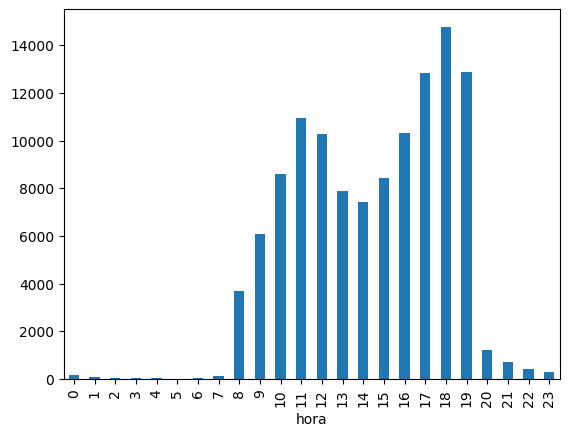

In [121]:
df_copy["hora"] = df_copy["Fecha"].dt.hour
df_copy["hora"].value_counts().sort_index().plot(kind="bar")
plt.show()

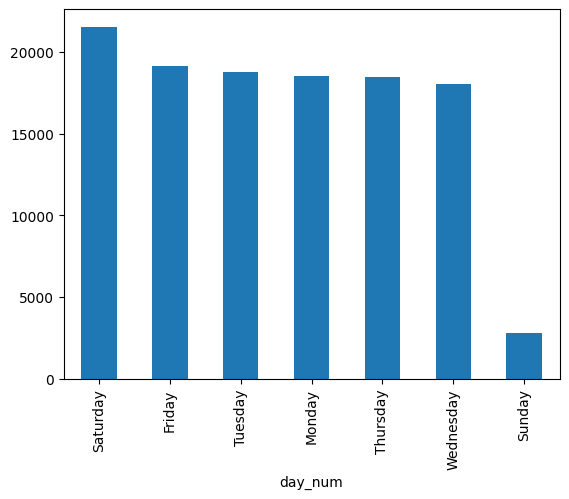

In [122]:
df_copy["day_num"] = df_copy["Fecha"].dt.day_name()
df_copy["day_num"].value_counts().plot(kind="bar")
plt.show()

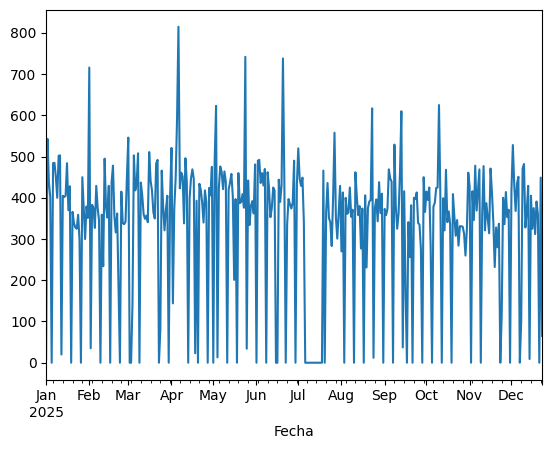

In [123]:
por_dia = df_copy.set_index("Fecha").resample("D").size()
por_dia.plot()
plt.show()

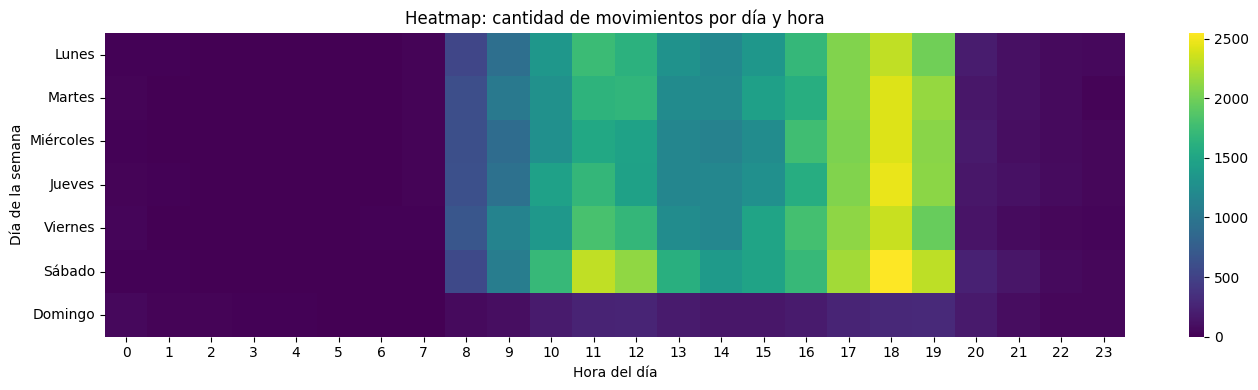

In [124]:
df_copy["day_num"] = df_copy["Fecha"].dt.dayofweek
df_copy["hour"] = df_copy["Fecha"].dt.hour
heat = pd.crosstab(df_copy["day_num"], df_copy["hour"])
heat = heat.reindex(index=range(7), columns=range(24), fill_value=0)
dias = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]
plt.figure(figsize=(14, 4))
sns.heatmap(heat, cmap="viridis") 
plt.yticks(ticks=[i+0.5 for i in range(7)], labels=dias, rotation=0)
plt.xticks(rotation=0)
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")
plt.title("Heatmap: cantidad de movimientos por día y hora")
plt.tight_layout()
plt.show()

In [125]:
cat_variables.remove("Producto")

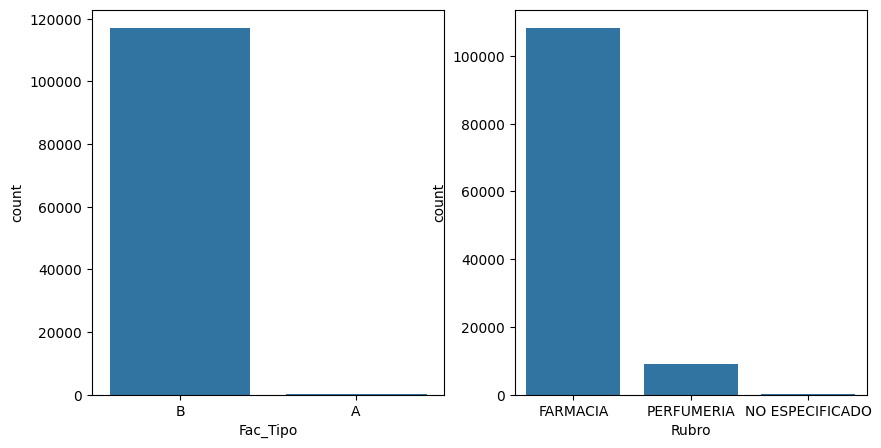

In [126]:
fig, axis = plt.subplots(1, 2, figsize=(10, 5))
sns.countplot(data=df, x=cat_variables[0], ax=axis[0])
sns.countplot(data=df, x=cat_variables[1], ax=axis[1])
plt.show()

### *Observaciones principales de los gráficos primeros:*

1. **Horas muertas en la madrugada**  
   Entre las 00:00 y las 07:00 prácticamente no hay movimientos. La farmacia presenta actividad casi nula en ese tramo horario, la mayor cantidad de días está cerrada de 20 hs a 8 am, pero hay días que le toca abrir y estar de turno/guardia zonal.

2. **Inicio fuerte de ventas desde la mañana**  
   A partir de las 08:00–09:00 las ventas aumentan notablemente y se mantienen altas durante el resto del día.

3. **Pico máximo al final de la tarde**  
   El mayor volumen de ventas se concentra alrededor de las 18:00–19:00, que puede considerarse el *prime time* del comercio.

4. **Caída brusca después de las 20:00**  
   Luego de las 20:00 se observa una disminución marcada en la cantidad de ventas. Es decir, la farmacia cierra a las 20 hs.

5. **El sábado es el día con más ventas**  
   El día sábado presenta el mayor volumen total de ventas de la semana.

6. **El domingo es el día más débil**  
   El domingo tiene un nivel de ventas muy inferior al resto, posiblemente por menor demanda u horario reducido. Al igual que las horas muertas, los días domingos la farmacia está cerrada al público, salvo excepciones que tenga que abrir por estar de turno/guardia zonal.

7. **Estabilidad entre martes y viernes**  
   Los días martes, miércoles, jueves y viernes muestran volúmenes de ventas muy similares entre sí.

8. **Patrón laboral en días de semana**  
   De lunes a viernes los picos de ventas se concentran entre 10–13 hs y 16–19 hs, típico comportamiento de clientes antes o después del trabajo.

9. **Doble pico los sábados**  
   El sábado se destaca por tener alta actividad tanto al mediodía como por la tarde-noche.

10. **Serie temporal estable con anomalías**  
    El nivel diario de ventas es relativamente estable, pero aparecen varios días con ventas en cero, lo que podría indicar cierres, faltantes de datos o errores de registro.
11. **Rubros diferenciados**  
    Se ve que se establecen dos rubros bien diferenciados, claramente el fuerte de la farmacia es la venta de medicamentos.
12. **Facturación**  
    En Argentina, el tipo de factura B es la más común cuando la compra la realiza un consumidor final, en cambio cuando una empresa u otra sociedad compra por grandes cantidad o volumenes, generalmente se realiza una factura de tipo A donde la carga impositiva es diferenciada y el comprador puede utilizarla a su favor en futuras rendiciones. En este caso, vemos que el mayor volumen es hacia consumidores finales.


### Variable `Producto`

> - Esta variable tiene muchos valores que son complicados de leer, como la trabajaremos a profundidad organizaremos y explicaremos en este espacio las decisiones que tomamos.

> - Empezaremos por pasar todas las variables a minusculas y cambiar las ","(comas) por "."(puntos).

In [127]:
df["Producto"] = df["Producto"].fillna("").astype(str).str.lower().str.replace(",", ".", regex=False)
df["Producto"].value_counts()

Producto
gen lp ibuprofeno blister 600 mg x 10             1925
gen lp omeprazol blister 20 mg x 15               1203
aspirina prevent comp.cub.enterica x 50           1149
tafirol 1g x 8 (unica)                             870
tafirol 1 g comp.ran.x 50                          699
                                                  ... 
cepillo dental (unica)                               1
proair bronquial 500/50 cáps.p/inh.x 60+aplic.       1
flevomax 1000 mg comp.rec.x 30                       1
pampers pants premium care xgd                       1
cepillo oral b (unica)                               1
Name: count, Length: 7663, dtype: int64

> - Procederemos a borrar todos los productos que se vendieron menos de 100 veces en todo el año de datos que tenemos.
> - Tambien haremos una revision a los nombres que tengan menos de 13 letras para verificar si queda algun error de tipografia donde no podamos sacar mas datos sobre el producto.

In [128]:
df = df[df["Producto"].map(df["Producto"].value_counts()) >= 100].copy()

In [129]:
mask = df["Producto"].fillna("").astype(str).str.len().le(12)
count_rows = mask.sum()
count_rows
df.loc[mask, "Producto"].astype(str).str.strip().value_counts()

Producto
dove (unica)    115
gum (unica)     108
Name: count, dtype: int64

In [130]:
df["Producto"].value_counts()

Producto
gen lp ibuprofeno blister 600 mg x 10            1925
gen lp omeprazol blister 20 mg x 15              1203
aspirina prevent comp.cub.enterica x 50          1149
tafirol 1g x 8 (unica)                            870
tafirol 1 g comp.ran.x 50                         699
                                                 ... 
aucic 1% sol.oft.x 10 ml                          101
ibupirac 600 capsula blanda cáps.blandas x 50     101
kala md comp.rec.x 28                             101
acc lp borato de sodio x 25 gr                    101
alplax 2 mg comp.x 30                             100
Name: count, Length: 189, dtype: int64

#### **Nuestro siguiente paso es realizar una categorizacion a partir de la columna `Producto` donde crearemos la columna `product, dose, quantity` para clasificar los productos y poder entender mejor los datos.**

> - Se procede a realizar un data clean sobre la columna: este paso fue muy laborioso ya que el dataset tenia mucho ruido en esta columna precisamente, tuvimos que investigar sobre los tipos de presentaciones de cada medicamento y cada narca, aquí recurrimos a la fuente principal de consulta de información de donde provino el dataset.

In [131]:
df[["product", "dose", "quantity"]] = pd.NA

In [132]:
dose_pat = r"""(?ix)(
    \b\d+(?:\.\d+)?\s*/\s*\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\s*/\s*\d+(?:\.\d+)?\s*(?:ml|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*%(?!\w)                
  | \b\d+\s*(?:dosis|ds)\b
  | (?<!\w)(?:unica|única)(?!\w))"""

df["dose"] = df["Producto"].str.findall(dose_pat).str.join(", ")
df["dose"] = df["dose"].str.replace(r"(?i)(?<!\w)(unica|única)(?!\w)", "UNICA", regex=True)
df["dose"] = df["dose"].replace("", np.nan)

> - Verificamos que productos quedan en blanco despues de nuestro filtro.

In [133]:
df[df["dose"].fillna("").eq("")][["Producto", "Rubro", "dose"]].value_counts()

Series([], Name: count, dtype: int64)

In [134]:
df[["Producto", "dose"]].value_counts()

Producto                                  dose     
gen lp ibuprofeno blister 600 mg x 10     600 mg       1925
gen lp omeprazol blister 20 mg x 15       20 mg        1203
tafirol 1g x 8 (unica)                    1g, UNICA     870
tafirol 1 g comp.ran.x 50                 1 g           699
gen lp diclofenac blister 75 mg x 15      75 mg         530
                                                       ... 
guantes (unica)                           UNICA         103
ultra corega crema sin sabor pomo x 20 g  20 g          103
vivita forte antigripal pouch x 1 x 5 g   5 g           103
aucic 1% sol.oft.x 10 ml                  1%            101
alplax 2 mg comp.x 30                     2 mg          100
Name: count, Length: 117, dtype: int64

> - Obtuvimos todas las dosis posibles y donde no existía un valor medible directamente decidimos dejarla en blanco con un NaN.
> - Ahora procederemos a trabajar la columna `quantity`.

In [135]:
prod = df["Producto"].fillna("").astype(str)

qty_pat = r"""(?ix)(
    
    \bx\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b           

  
    \b(?:pomo|frasco|vial|amp(?:olla)?|sobre|sachet)\s*x?\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b

  
    \b(?:pack|caja|env|sobre|sob|blister|blíster|test|aplic)\.?\s*x\s*\d{1,4}\s*(?:ds|dosis)?\b


    \b(?:comp|comprimidos?|caps?|cáps?|grag|tab(?:s)?)(?:\.\w+)?\.?\s*x\s*\d{1,4}\b


    \bx\s*\d{1,4}\s*(?:ds|dosis)?\b


    \b\d{1,3}x\d{1,3}\b)"""

df["quantity"] = prod.str.findall(qty_pat).str.join(", ")
df["quantity"] = df["quantity"].replace("", np.nan)


/tmp/ipykernel_2503/1255969322.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["quantity"] = df["quantity"].replace("", np.nan)


In [136]:
df[["Producto", "dose"]].value_counts().head(20)

Producto                                  dose     
gen lp ibuprofeno blister 600 mg x 10     600 mg       1925
gen lp omeprazol blister 20 mg x 15       20 mg        1203
tafirol 1g x 8 (unica)                    1g, UNICA     870
tafirol 1 g comp.ran.x 50                 1 g           699
gen lp diclofenac blister 75 mg x 15      75 mg         530
corbis 5 mg comp.rec.x 30                 5 mg          471
alikal (unica)                            UNICA         451
t4 montpellier 75 75 mcg comp.x 50        75 mcg        446
t4 montpellier 50 50 mcg comp.x 50        50 mcg        423
t4 montpellier 100 100 mcg comp.x 50      100 mcg       386
gen lp ibuprofeno blister 400 mg x 10     400 mg        368
acemuk 600 mg tab.eferv.x 10              600 mg        350
lotrial 10 mg comp.x 60                   10 mg         344
gen lp loratadina blister 10 mg x 10      10 mg         336
losacor 50 mg comp.rec.x 60               50 mg         306
carey (unica)                             UNICA 

> - Obtuvimos todas las cantidades posibles y donde no existia un valor medible directamente decidimos dejarla en blanco con un NaN.
> - Ahora procederemos a trabajar la columna `product`.

In [137]:
prod = df["Producto"].fillna("").astype(str)

dose_pat = r"""(?ix)(
    \b\d+(?:\.\d+)?\s*/\s*\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\s*/\s*\d+(?:\.\d+)?\s*(?:ml|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*%(?!\w)
  | \b\d+\s*(?:dosis|ds)\b
  | (?<!\w)(?:unica|única)(?!\w))"""

qty_remove_pat = r"""(?ix)(
    \bx\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b
  | \b(?:pack|caja|env|sobre|sob|blister|blíster|test|aplic)\.?\s*x\s*\d{1,4}\s*(?:ds|dosis)?\b
  | \b(?:comp|comprimidos?|caps?|cáps?|grag|tab(?:s)?)(?:\.\w+)?\.?\s*x\s*\d{1,4}\b
  | \bx\s*\d{1,4}\s*(?:ds|dosis)?\b
  | \b\d{1,3}x\d{1,3}\b)"""

p = (prod
     .str.replace(dose_pat, " ", regex=True)
     .str.replace(qty_remove_pat, " ", regex=True))


p = p.str.replace(r"(?ix)\s+\d{1,4}(?:\.\d+)?\s*$", " ", regex=True)

p = p.str.replace(r"(?ix)(?<!\w)x(?!\w)", " ", regex=True)

dose_num = df["dose"].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand=False)

def drop_repeated_num(text, num):
    if not isinstance(num, str) or num == "" or num.lower() == "nan":
        return text
    return re.sub(rf"(?<!\w){re.escape(num)}(?!\w)", " ", text)

p = pd.Series(
    (drop_repeated_num(t, n) for t, n in zip(p.tolist(), dose_num.tolist())),index=df.index)

df["product"] = (p
    .str.replace(r"[^\w\sáéíóúñü]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .replace("", np.nan))

df["product"] = df["product"].str.replace(
    r"(?ix)\b(\w+)\b(?:\s+\1\b)+", r"\1", regex=True)

In [138]:
df["product"].isna().sum()

np.int64(0)

In [140]:
def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFKD", s)
    return "".join(ch for ch in s if not unicodedata.combining(ch))

def norm(s) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = strip_accents(s)
    s = re.sub(r"\s+", " ", s)
    return s


EXACT = {
    
    "ibuprofeno": "ibuprofeno",
    "paracetamol": "paracetamol",
    "omeprazol": "omeprazol",
    "losartan": "losartán",
    "enalapril": "enalapril",
    "bisoprolol": "bisoprolol",
    "alprazolam": "alprazolam",
    "clonazepam": "clonazepam",
    "lactulosa": "lactulosa",
    "loratadina": "loratadina",
    "diclofenaco": "diclofenaco",
    "acetilcisteina": "acetilcisteína",
    "rosuvastatina": "rosuvastatina",
    "levotiroxina": "levotiroxina",
    "acido acetilsalicilico": "ácido acetilsalicílico",
    "acido acetilsalicilico + cafeina": "ácido acetilsalicílico + cafeína",
    "diclofenaco + pridinol": "diclofenaco + pridinol",
    "propinox + clonixinato de lisina": "propinox + clonixinato de lisina",
    "butilbromuro de hioscina + metamizol": "butilbromuro de hioscina + metamizol",
    "amoxicilina": "amoxicilina",
    "amoxicilina + acido clavulanico": "amoxicilina + ácido clavulánico",
    "colecalciferol (vitamina d3)": "colecalciferol (vitamina d3)",

    "tafirol": "paracetamol",
    "tafirol 500": "paracetamol",
    "tafirol forte": "paracetamol",
    "tafirol blister": "paracetamol",
    "geniol comp": "paracetamol",
    "mejoral paracetamol": "paracetamol",
    "paracetamol bayer": "paracetamol",
    "paracetamol raffo": "paracetamol",
    "paracetamol lazar": "paracetamol",
    "paracetamol teva": "paracetamol",

    "aspirina prevent comp cub enterica": "ácido acetilsalicílico",
    "bayaspirina": "ácido acetilsalicílico",
    "bayaspirina forte": "ácido acetilsalicílico",
    "aspirinetas": "ácido acetilsalicílico",
    "cafiaspirina": "ácido acetilsalicílico + cafeína",

    "t4 montpellier": "levotiroxina",
    "euthyrox": "levotiroxina",

    "lotrial": "enalapril",
    "corbis": "bisoprolol",
    "losacor": "losartán",
    "paxon": "losartán",
    "alplax": "alprazolam",
    "alplax net": "alprazolam",

    "rivotril": "clonazepam",
    "clonagin": "clonazepam",
    "clonagin sl": "clonazepam",
    "diocam": "clonazepam",
    "diocam sl": "clonazepam",

    "lactulon jbe": "lactulosa",

    "buscapina": "butilbromuro de hioscina",
    "buscapina fem": "butilbromuro de hioscina",
    "buscapina perlas": "butilbromuro de hioscina",
    "buscapina duo": "butilbromuro de hioscina",
    "buscapina duo got": "butilbromuro de hioscina",
    "buscapina compuesta": "butilbromuro de hioscina + metamizol",
    "buscapina compositum comp rec": "butilbromuro de hioscina + metamizol",

    "sertal": "propinox",
    "sertal perlas": "propinox",
    "sertal gts": "propinox",
    "sertal compuesto": "propinox + clonixinato de lisina",
    "sertal compuesto vl": "propinox + clonixinato de lisina",

    "ibupirac": "ibuprofeno",
    "actron 600 rapida accion caps gelat blanda": "ibuprofeno",
    "fabogesic 600 rapida accion cáps gelat blanda": "ibuprofeno",

    "acemuk": "acetilcisteína",
    "osteodyn": "colecalciferol (vitamina d3)",
    "osteodyn sol oral": "colecalciferol (vitamina d3)",
    "raquiferol d3 sol oral": "colecalciferol (vitamina d3)",
    "raquiferol d3 100000 ui": "colecalciferol (vitamina d3)",
    "sterogyl f a beb": "colecalciferol (vitamina d3)",
    "sinlip": "rosuvastatina",

    "gadopril": "enalapril",

  
    "valium": "diazepam",
    "zoloft": "sertralina",
    "asertral": "sertralina",
    "lexotanil": "bromazepam",
    "lexapro": "escitalopram",
    "aropax": "paroxetina",
    "paxil cr": "paroxetina",
    "dramamine": "dimenhidrinato",
    "reliveran": "metoclopramida",
    "novalgina": "metamizol",
    "novalgina jbe": "metamizol",
    "bactrim": "sulfametoxazol + trimetoprima",
    "bactrim forte": "sulfametoxazol + trimetoprima",
    "glucophage": "metformina",
    "glucophage xr comp lib prol": "metformina",
    "dbi metformina": "metformina",
    "dbi ap metformina": "metformina",
    "forxiga": "dapagliflozina",
    "lipitor": "atorvastatina",
    "atorvastatin richet": "atorvastatina",
    "atorvastan": "atorvastatina",
    "ventolin hfa aer inh c": "salbutamol",
    "ventolin sol p nebul": "salbutamol",
    "salbutral aer": "salbutamol",
    "atrovent hfa aerosol hfa": "ipratropio",
    "seretide diskus dosis": "fluticasona + salmeterol",
    "symbicort turbuhaler dosis": "budesonida + formoterol",
    "anoro ellipta pvo inh": "umeclidinio + vilanterol",

    "amoxidal": "amoxicilina",
    "amoxidal ped susp": "amoxicilina",
    "amoxidal duo": "amoxicilina + ácido clavulánico",
    "amoxidal duo susp": "amoxicilina + ácido clavulánico",
    "optamox duo": "amoxicilina + ácido clavulánico",
    "optamox duo susp": "amoxicilina + ácido clavulánico",
    "amixen clavulanico": "amoxicilina + ácido clavulánico",
    "amixen duo": "amoxicilina + ácido clavulánico",
    "amoclav duo": "amoxicilina + ácido clavulánico",}

GENERIC_PATTERNS = [
    (r"\bibuprofeno\b", "ibuprofeno"),
    (r"\bparacetamol\b", "paracetamol"),
    (r"\bdiclofenac", "diclofenaco"),
    (r"\bnaproxeno\b", "naproxeno"),
    (r"\bketorolac\b", "ketorolac"),
    (r"\ballopurinol\b", "allopurinol"),
    (r"\batenolol\b", "atenolol"),
    (r"\bpropranolol\b", "propranolol"),
    (r"\bcarvedilol\b", "carvedilol"),
    (r"\bclopidogrel\b", "clopidogrel"),
    (r"\bmetformina\b", "metformina"),
    (r"\batorvastat", "atorvastatina"),
    (r"\brosuvastatina\b", "rosuvastatina"),
    (r"\bespironolactona\b", "espironolactona"),
    (r"\bfurosemida\b", "furosemida"),
    (r"\blosartan\b", "losartán"),
    (r"\benalapril\b", "enalapril"),
    (r"\bbisoprolol\b", "bisoprolol"),
    (r"\bomeprazol\b", "omeprazol"),
    (r"\blesomeprazol\b", "esomeprazol"),
    (r"\blevotiroxina\b", "levotiroxina"),
    (r"\bamoxicilina\b", "amoxicilina"),
    (r"\bcefalexina\b", "cefalexina"),
    (r"\bclindamicina\b", "clindamicina"),
    (r"\bciprofloxacina\b", "ciprofloxacina"),
    (r"\bnorfloxacina\b", "norfloxacina"),
    (r"\bazitromicina\b", "azitromicina"),
    (r"\bfluconazol\b", "fluconazol"),
    (r"\bnistatina\b", "nistatina"),
    (r"\bsildenafil\b", "sildenafil"),
    (r"\baciclovir\b", "aciclovir"),
    (r"\bcarbamazepina\b", "carbamazepina"),
    (r"\blamotrig", "lamotrigina"),
    (r"\bmemantina\b", "memantina"),
    (r"\bfinaster", "finasterida"),
    (r"\btamsulosina\b", "tamsulosina"),
    (r"\bsertralina\b", "sertralina"),
    (r"\bfluoxet", "fluoxetina"),
    (r"\bes(c|s)italopram\b", "escitalopram"),
    (r"\bparoxetina\b", "paroxetina"),
    (r"\bdiazepam\b", "diazepam"),
    (r"\bbromazepam\b", "bromazepam"),
    (r"\brisperid", "risperidona"),
    (r"\bquetiapin", "quetiapina"),
    (r"\bhaloperidol\b", "haloperidol"),
    (r"\bloratadina\b", "loratadina"),
    (r"\bdifenhidramina\b", "difenhidramina"),
    (r"\bsalbutamol\b", "salbutamol"),
    (r"\bipratropio\b", "ipratropio"),
    (r"\bfluticasona\b", "fluticasona"),
    (r"\bsalmeterol\b", "salmeterol"),
    (r"\bbudesonida\b", "budesonida"),
    (r"\bformoterol\b", "formoterol"),
    (r"\bmometasona\b", "mometasona"),
    (r"\bmetoclopramida\b", "metoclopramida"),
    (r"\bmetamizol\b", "metamizol"),
    (r"\bacetilcisteina\b", "acetilcisteína"),
    (r"\blactulosa\b", "lactulosa"),
    (r"\bcolecalciferol\b", "colecalciferol (vitamina d3)"),
    (r"\bcalcitriol\b", "calcitriol"),
    (r"\blidocaina\b", "lidocaína"),
    (r"\bterbinafina\b", "terbinafina"),
    (r"\bbeta(histina)?\b", "betahistina"),
    (r"\bdapaglifloz", "dapagliflozina"),]

AMBIGUOUS = {
    "carey",
    "diurex", "diurex a",
    "qura", "qura plus",
    "migral", "migral ii", "migral compuesto", "migral compositum",
    "alikal", "alikal expend c prosp",
    "refrianex", "refrianex compuesto",
    "mylanta", "mylanta extra", "mylanta ii", "mylanta simple liq", "mylanta limon",
    "mylanta frut silv", "mylanta tabletas", "mylanta extra tableta",
    "supradyn forte", "supradyn pronatal", "supradyn forte eferv nar s az",
    "berocca plus",
    "uvasal sob doble", "uvasal naranja sob doble", "uvasal limon sob doble",
    "uvasal naranja fco", "uvasal fco plast",
    "next", "next forte", "next plus",
    "vick vitapyrena", "vick vitapyrena forte miel limon", "vick forte",
    "vick vaporub lata", "vick vaporub pote",
    "redoxon eferv limon", "redoxon eferv",
    "redoxitos plus sachets gomitas", "redoxitos naranja masticables sachets gomitas",
    "centrum mujer", "centrum silver",
    "corbis d", "lotrial d", "losacor a", "losacor d", "gadopril d",
    "paxon d", "losartan richet trzb",}

def map_active(product_name: str):
    s0 = norm(product_name)
    if not s0:
        return "Desconocido", "empty"

 
    if s0 in AMBIGUOUS:
        return "Desconocido", "ambiguous_or_unknown"

    
    if s0.startswith("gen lp "):
        rest = s0.replace("gen lp ", "", 1).strip()
        rest = rest.replace("clavulanico", "acido clavulanico")

        if rest in EXACT:
            return EXACT[rest], "gen_lp_exact"

        for pat, active in GENERIC_PATTERNS:
            if re.search(pat, rest):
                return active, "gen_lp_pattern"

        return "Desconocido", "gen_lp_unresolved"

   
    if s0 in EXACT:
        return EXACT[s0], "exact"

  
    for pat, active in GENERIC_PATTERNS:
        if re.search(pat, s0):
            return active, "pattern"

 
    if re.search(r"\b(acc lp|perfumeria|accesorio|guantes|curita|curitas|barbijo|test|algodon|gasa|jeringa|venda|cepillo|colgate|dove|nivea|gillette|labello|listerine|rexona|ponds|garnier|pantene)\b", s0):
        return "Desconocido", "non_drug_or_device"

    return "Desconocido", "unknown"

mapped = df["product"].apply(map_active)

active = mapped.apply(lambda x: x[0])

mask = active != "Desconocido"
df.loc[mask, "product"] = active[mask]
print("Reemplazados:", int(mask.sum()))

Reemplazados: 20874


In [141]:
df

,Fecha,Fac_Tipo,Fac_Nun,Cant,Precio,Producto,Sub_Total,Rubro,Cobertura,Desc_Adic,Total_Cliente,IVA,Tasa_Iva,Total_Gravado,Total_sin_Gravar,num_semana,product,dose,quantity
8,2025-01-01 07:46:36,B,379930,2,3500.00,accesorio (unica),7000.00,FARMACIA,0.00,0.0,7000.00,1214.876033,21,5785.123967,0.00,1,accesorio,UNICA,NaN
9,2025-01-02 08:08:38,B,379931,1,3430.00,qura plus comp.rec.x 20,3430.00,FARMACIA,0.00,343.0,3087.00,0.000000,0,0.000000,3430.00,1,qura plus,NaN,NaN
13,2025-01-02 08:44:01,B,379935,1,4500.00,acc lp gasa esteril no 5 caja 10 x 10,4500.00,FARMACIA,0.00,0.0,4500.00,780.991736,21,3719.008264,0.00,1,acc lp gasa esteril no 5 caja,NaN,NaN
15,2025-01-02 08:44:01,B,379935,1,1000.00,acc lp agua oxigenada 10 vol\tx 100 cc,1000.00,FARMACIA,0.00,0.0,1000.00,173.553719,21,826.446281,0.00,1,acc lp agua oxigenada 10 vol,NaN,NaN
16,2025-01-02 08:44:01,B,379935,1,800.00,curitas (unica),800.00,FARMACIA,0.00,0.0,800.00,0.000000,0,0.000000,800.00,1,curitas,UNICA,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117281,2025-12-23 10:03:35,B,455857,2,18005.59,levotiroxina gsk 75 mcg comp.x 50,36011.18,FARMACIA,17077.54,0.0,18933.64,0.000000,0,0.000000,36011.18,52,levotiroxina,75 mcg,NaN
117286,2025-12-23 10:17:33,B,455860,1,14800.00,ultra corega crema sin sabor pomo x 70 g,14800.00,FARMACIA,0.00,0.0,14800.00,2568.595041,21,12231.404960,0.00,52,ultra corega crema sin sabor pomo,70 g,NaN
117288,2025-12-23 10:23:06,B,455861,8,13500.00,mylanta extra comp.mast.x 24,4500.00,FARMACIA,0.00,0.0,4500.00,0.000000,0,0.000000,4500.00,52,mylanta extra,NaN,NaN
117289,2025-12-23 10:23:06,B,455861,1,5000.00,colgate (unica),5000.00,FARMACIA,0.00,0.0,5000.00,0.000000,0,0.000000,5000.00,52,colgate,UNICA,NaN


In [142]:
df[["product"]].value_counts()

product                                               
ibuprofeno                                                3162
paracetamol                                               2602
levotiroxina                                              2588
ácido acetilsalicílico                                    1378
omeprazol                                                 1203
                                                          ... 
bisofec                                                    103
acc lp tela antialergica 3m de1 25 s racionador microp     102
acc lp borato de sodio                                     101
aucic sol oft                                              101
kala md                                                    101
Name: count, Length: 134, dtype: int64

In [143]:
(df["product"] != "Desconocido").sum()

np.int64(41107)

In [144]:
df.drop(columns=["quantity"], errors="ignore", inplace=True)

In [146]:
num_variables = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
num_variables

['Fac_Nun',
 'Cant',
 'Precio',
 'Sub_Total',
 'Cobertura',
 'Desc_Adic',
 'Total_Cliente',
 'IVA',
 'Tasa_Iva',
 'Total_Gravado',
 'Total_sin_Gravar',
 'num_semana']

In [147]:
df[num_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
Fac_Nun,41107.0,417039.481548,22146.952437,379930.00,398028.00,415255.00,436511.000,455862.00000
Cant,41107.0,1.433722,1.743754,0.00,1.00,1.00,1.000,48.00000
Precio,41107.0,10384.595184,9065.898011,30.00,4000.00,7730.00,13800.000,98000.00000
Sub_Total,41107.0,10813.035250,9741.467582,0.00,4100.00,7780.24,13974.980,160000.00000
Cobertura,41107.0,4450.618100,7984.717235,-157953.92,0.00,0.00,6842.331,104049.86000
Desc_Adic,41107.0,12.203385,312.505848,-31312.40,0.00,0.00,0.000,14380.43000
Total_Cliente,41107.0,6350.213765,5570.640485,0.00,2883.63,5000.00,8150.000,178298.57000
IVA,41107.0,123.055567,414.069019,0.00,0.00,0.00,0.000,27768.59504
Tasa_Iva,41107.0,3.081008,7.430337,0.00,0.00,0.00,0.000,21.00000
Total_Gravado,41107.0,585.978892,1971.757231,0.00,0.00,0.00,0.000,132231.40500


In [148]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Fecha,41107,2025-06-22 13:42:13.804412672,2025-01-01 07:46:36,2025-03-29 08:23:06,2025-06-12 17:07:58,2025-09-19 08:49:54,2025-12-23 10:25:57,NaN
Fac_Nun,41107.0,417039.481548,379930.0,398028.0,415255.0,436511.0,455862.0,22146.952437
Cant,41107.0,1.433722,0.0,1.0,1.0,1.0,48.0,1.743754
Precio,41107.0,10384.595184,30.0,4000.0,7730.0,13800.0,98000.0,9065.898011
Sub_Total,41107.0,10813.03525,0.0,4100.0,7780.24,13974.98,160000.0,9741.467582
Cobertura,41107.0,4450.6181,-157953.92,0.0,0.0,6842.331,104049.86,7984.717235
Desc_Adic,41107.0,12.203385,-31312.4,0.0,0.0,0.0,14380.43,312.505848
Total_Cliente,41107.0,6350.213765,0.0,2883.63,5000.0,8150.0,178298.57,5570.640485
IVA,41107.0,123.055567,0.0,0.0,0.0,0.0,27768.59504,414.069019
Tasa_Iva,41107.0,3.081008,0.0,0.0,0.0,0.0,21.0,7.430337


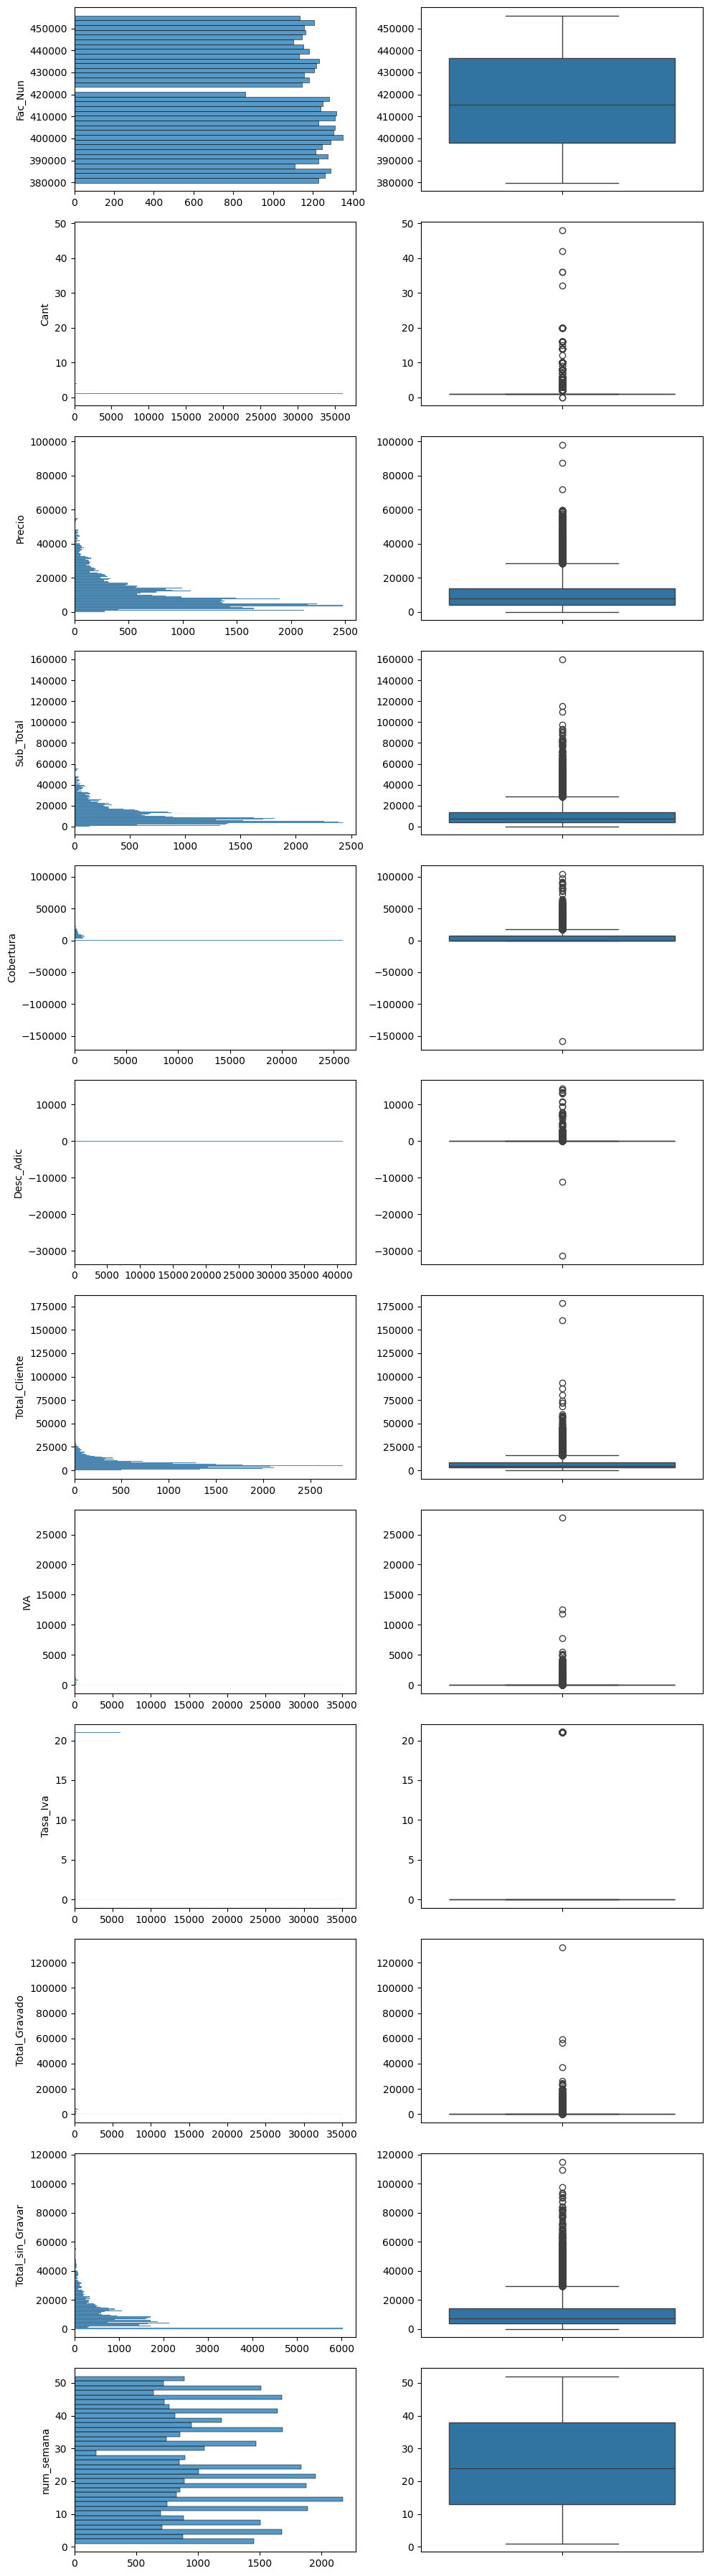

In [149]:
fig, axis = plt.subplots(len(num_variables), 2, figsize=(10, 3*len(num_variables)))

for i, var in enumerate(num_variables):
    sns.histplot(ax=axis[i, 0], data=df, y=var).set(xlabel=None)
    sns.boxplot(ax=axis[i, 1], data=df, y=var).set(ylabel=None)


plt.tight_layout()
plt.show()

#### Observaciones.

`Fac. Suc.` - Todos sus valores estan en 0, en una columna que no nos dice nada.  
`Fac. Nun.` - Es el numero de factura, como un id, tampoco nos aporta mucho a lo que buscamos.    
`Cant.` - Aunque la mayoria tienen como valor 1, el resto de outliner parecen ser reales, la conservaremos para tratarla detalladamente mas adelante.  
`Precio` - Es el precio por unidad que tiene un producto  
`Sub. Total` - Es el resultado de multiplicar el precio por cantidad   
`Cobertura` - Es lo que cubre la seguridad social.   
`Ajustes` - Todos sus valores estan en 0, en una columna que no nos dice nada.  
`Desc. Adic.` - Aunque la mayoria de los valores estan en 0, tiene numeros en negativos y positivos, tambien revisaremos a profundidad.  
`Total. Cliente` -  La mayoria de valores esta entre 0 y 25000, tiene varios outliners que debemos tomar en cuenta.  
`IVA` -  Esta variable va desde el 0 al 160000, tiene sentido ya que sera el iva por producto.  
`Tasa Iva` - esta entre 0, 10% y 21%    
`Total Gravado` -  los valores principalmente estan en 0, pero notamos algunos outliners que revisaremos a detalle  
`Total sin Gravar` -   Los valores estan entre 0 y 60000 aproximadamente, encontramos varios outliners que analizaremos lo que nos dice mas adelante.  

In [150]:
df = df.drop(columns=["Fac. Suc", "Fac. Nun.", "Ajustes"], errors="ignore")

In [152]:
df.columns

Index(['Fecha', 'Fac_Tipo', 'Fac_Nun', 'Cant', 'Precio', 'Producto',
       'Sub_Total', 'Rubro', 'Cobertura', 'Desc_Adic', 'Total_Cliente', 'IVA',
       'Tasa_Iva', 'Total_Gravado', 'Total_sin_Gravar', 'num_semana',
       'product', 'dose'],
      dtype='object')

In [154]:
df[["Producto", "Precio", "Sub_Total", "Cant", "Cobertura", "Desc_Adic", "Tasa_Iva", "IVA","Total_Gravado", "Total_sin_Gravar", "Total_Cliente"]].head(10)

,Producto,Precio,Sub_Total,Cant,Cobertura,Desc_Adic,Tasa_Iva,IVA,Total_Gravado,Total_sin_Gravar,Total_Cliente
8,accesorio (unica),3500.0,7000.0,2,0.0,0.0,21,1214.876033,5785.123967,0.0,7000.0
9,qura plus comp.rec.x 20,3430.0,3430.0,1,0.0,343.0,0,0.000000,0.000000,3430.0,3087.0
13,acc lp gasa esteril no 5 caja 10 x 10,4500.0,4500.0,1,0.0,0.0,21,780.991736,3719.008264,0.0,4500.0
15,acc lp agua oxigenada 10 vol\tx 100 cc,1000.0,1000.0,1,0.0,0.0,21,173.553719,826.446281,0.0,1000.0
16,curitas (unica),800.0,800.0,1,0.0,0.0,0,0.000000,0.000000,800.0,800.0
20,acc lp gasa esteril no 5 caja 10 x 10,4500.0,4500.0,1,0.0,0.0,21,780.991736,3719.008264,0.0,4500.0
22,gen lp ibuprofeno blister 600 mg x 10,3500.0,3500.0,1,0.0,0.0,0,0.000000,0.000000,3500.0,3500.0
31,rhinal gts.x 30 ml,5360.0,5360.0,1,0.0,0.0,0,0.000000,0.000000,5360.0,5360.0
32,sertal compuesto comp.rec.x 20,11200.0,5600.0,10,0.0,0.0,0,0.000000,0.000000,5600.0,5600.0
33,ventolin hfa aer.inh.c/aplic.x200ds.,17470.0,17470.0,1,0.0,0.0,0,0.000000,0.000000,17470.0,17470.0
